# Credit Card Default Prediction

## Project goal
This notebook predicts whether a credit card customer is likely to default on their next payment, using demographic details, credit limit, billing history, and past payment behaviour.

**Dataset:** UCI Default of Credit Card Clients  
**Target:** `default_payment_next_month`  
**Author:** Rachit Dhakad

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Download the official UCI credit-default dataset
credit_default = fetch_ucirepo(id=350)

# Put customer details and the default outcome into one table
X = credit_default.data.features
y = credit_default.data.targets
df = pd.concat([X, y], axis=1)

# Save a copy inside this project
df.to_csv("data/credit_default_clients.csv", index=False)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (30000, 24)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 1. Load and Understand the Data

Before training a model, we need to inspect the columns, check for missing values, and see how many customers did and did not default.

In [3]:
# See the column names and data types
df.info()

# Check whether any values are missing
print("\nMissing values in each column:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

# Find the outcome column and count defaults vs non-defaults
target_column = y.columns[0]

print(f"\nTarget column: {target_column}")
print("\nDefault outcome counts:")
display(df[target_column].value_counts())

print("\nDefault outcome percentages:")
display((df[target_column].value_counts(normalize=True) * 100).round(2))

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  Y       30000 non-null

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
dtype: int64


Target column: Y

Default outcome counts:


Y
0    23364
1     6636
Name: count, dtype: int64


Default outcome percentages:


Y
0    77.88
1    22.12
Name: proportion, dtype: float64

## 2. Data Cleaning

The dataset has no missing values. We will rename the target column clearly and remove the customer ID, because an ID is only a label—not useful information for predicting default.

In [4]:
# Give the target column a clear name
df = df.rename(columns={target_column: "default_payment_next_month"})
target_column = "default_payment_next_month"

# Remove the customer ID because it has no predictive meaning
if "ID" in df.columns:
    df = df.drop(columns="ID")

# Save the cleaned dataset
df.to_csv("data/credit_default_clients_cleaned.csv", index=False)

print(f"Cleaned dataset shape: {df.shape}")
print("\nFirst 10 column names:")
print(df.columns[:10].tolist())

Cleaned dataset shape: (30000, 24)

First 10 column names:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']


### Make column names readable

In [5]:
column_names = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6"
}

df = df.rename(columns=column_names)

# Save the improved version
df.to_csv("data/credit_default_clients_cleaned.csv", index=False)

print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_payment_next_month']


## 3. Exploratory Data Analysis

### Default Distribution

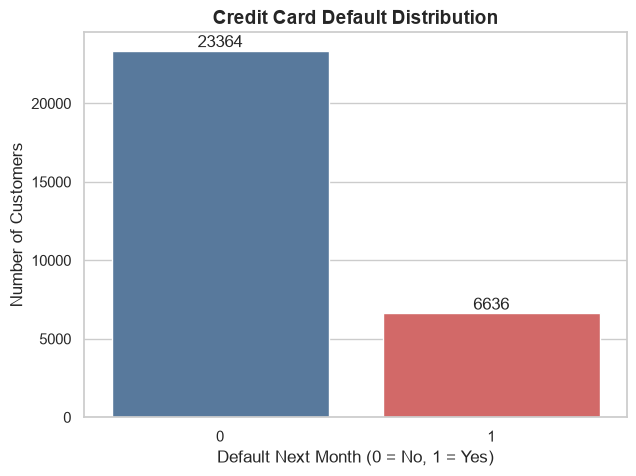

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x=target_column,
    hue=target_column,
    palette=["#4C78A8", "#E45756"],
    legend=False
)

plt.title("Credit Card Default Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Default Next Month (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Default Rate by Gender

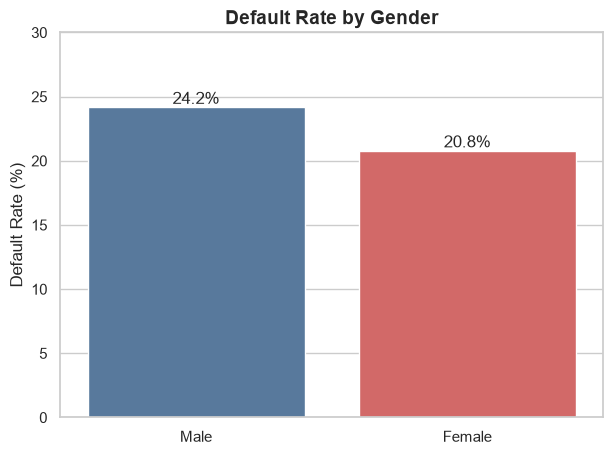

In [7]:
gender_default_rate = (
    df.groupby("SEX")[target_column]
    .mean()
    .mul(100)
    .rename({1: "Male", 2: "Female"})
    .reset_index()
)

gender_default_rate.columns = ["Gender", "Default Rate (%)"]

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=gender_default_rate,
    x="Gender",
    y="Default Rate (%)",
    hue="Gender",
    palette=["#4C78A8", "#E45756"],
    legend=False
)

plt.title("Default Rate by Gender", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Default Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 30)
plt.show()

### Default Rate by Recent Repayment Status

`PAY_0` describes the customer's repayment status in the most recent month. Higher positive values mean a longer payment delay.

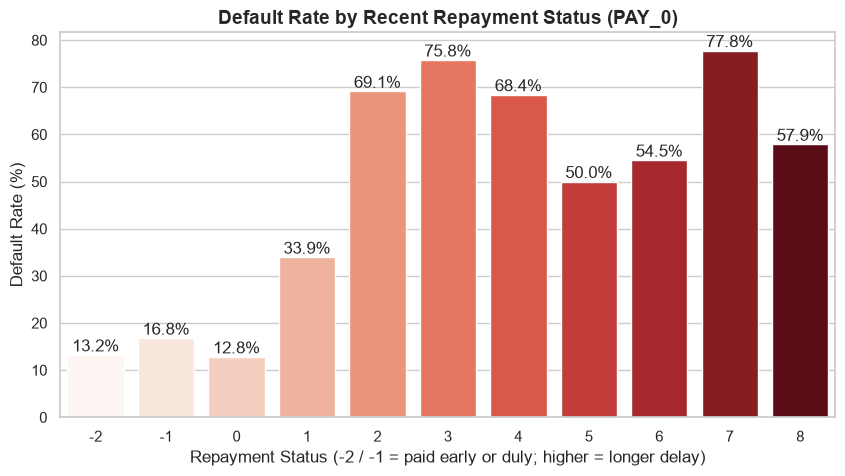

In [8]:
pay_status_default_rate = (
    df.groupby("PAY_0")[target_column]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("PAY_0")
)

pay_status_default_rate.columns = ["Recent Repayment Status", "Default Rate (%)"]

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=pay_status_default_rate,
    x="Recent Repayment Status",
    y="Default Rate (%)",
    hue="Recent Repayment Status",
    palette="Reds",
    legend=False
)

plt.title("Default Rate by Recent Repayment Status (PAY_0)", fontsize=14, fontweight="bold")
plt.xlabel("Repayment Status (-2 / -1 = paid early or duly; higher = longer delay)")
plt.ylabel("Default Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

## 4. Feature Preparation

### Clean category codes

In [9]:
# EDUCATION: 1 = graduate school, 2 = university, 3 = high school, 4 = other
# Values 0, 5, and 6 are undocumented, so group them as "other" (4).
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: 1 = married, 2 = single, 3 = other
# Group undocumented value 0 as "other" (3).
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

# Save the final cleaned dataset
df.to_csv("data/credit_default_clients_cleaned.csv", index=False)

print("Education categories:")
display(df["EDUCATION"].value_counts().sort_index())

print("Marriage categories:")
display(df["MARRIAGE"].value_counts().sort_index())

Education categories:


EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

Marriage categories:


MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

### Train-Test Split

We keep 20% of the data unseen during training so we can evaluate the model honestly.

In [10]:
from sklearn.model_selection import train_test_split

# X = customer information used to make predictions
# y = the answer we want the model to learn
X = df.drop(columns=target_column)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nDefault rate in training data:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDefault rate in testing data:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training data shape: (24000, 23)
Testing data shape: (6000, 23)

Default rate in training data:
default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64

Default rate in testing data:
default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64


## 5. Model Training

### Model 1: Logistic Regression

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model 1 Evaluation

Logistic Regression Results
-----------------------------------
Accuracy:  0.679
Precision: 0.367
Recall:    0.620
F1 Score:  0.461

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000



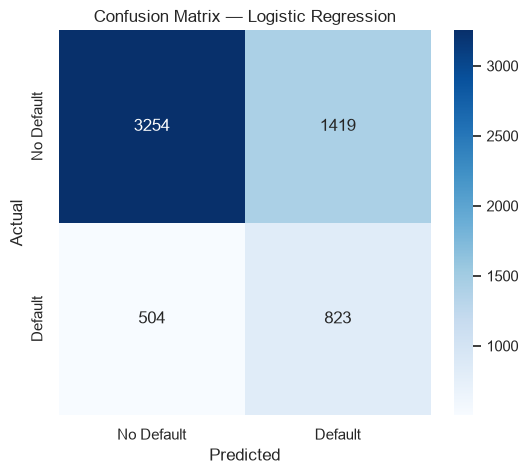

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Make predictions on unseen test data
y_pred_logistic = logistic_model.predict(X_test)

# Calculate evaluation metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy:  {accuracy_logistic:.3f}")
print(f"Precision: {precision_logistic:.3f}")
print(f"Recall:    {recall_logistic:.3f}")
print(f"F1 Score:  {f1_logistic:.3f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_logistic))

# Confusion matrix chart
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Model 2: Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Model 2 Evaluation

Random Forest Results
-----------------------------------
Accuracy:  0.799
Precision: 0.553
Recall:    0.489
F1 Score:  0.519


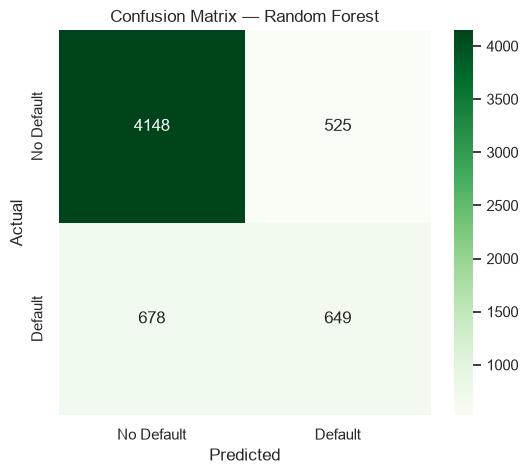

In [15]:
# Make predictions on unseen test data
y_pred_rf = random_forest_model.predict(X_test)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy:  {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall:    {recall_rf:.3f}")
print(f"F1 Score:  {f1_rf:.3f}")

# Confusion matrix chart
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Model 3: Gradient Boosting

In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier

gradient_boosting_model = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=300,
    class_weight="balanced",
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


### Model 3 Evaluation

Gradient Boosting Results
-----------------------------------
Accuracy:  0.764
Precision: 0.475
Recall:    0.619
F1 Score:  0.537


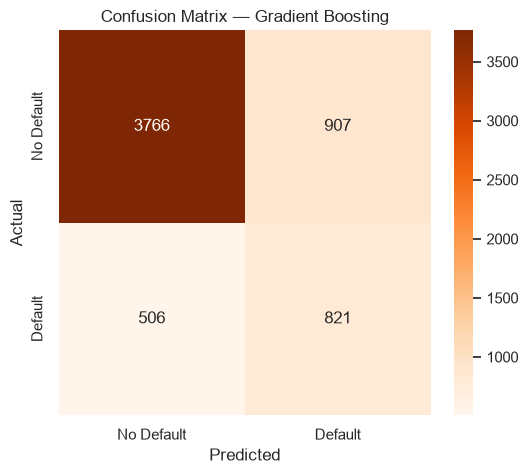

In [17]:
# Make predictions on unseen test data
y_pred_gb = gradient_boosting_model.predict(X_test)

# Calculate evaluation metrics
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-" * 35)
print(f"Accuracy:  {accuracy_gb:.3f}")
print(f"Precision: {precision_gb:.3f}")
print(f"Recall:    {recall_gb:.3f}")
print(f"F1 Score:  {f1_gb:.3f}")

# Confusion matrix chart
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix — Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 6. Model Comparison and Final Selection

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.764,0.475,0.619,0.537
1,Random Forest,0.799,0.553,0.489,0.519
2,Logistic Regression,0.679,0.367,0.620,0.461


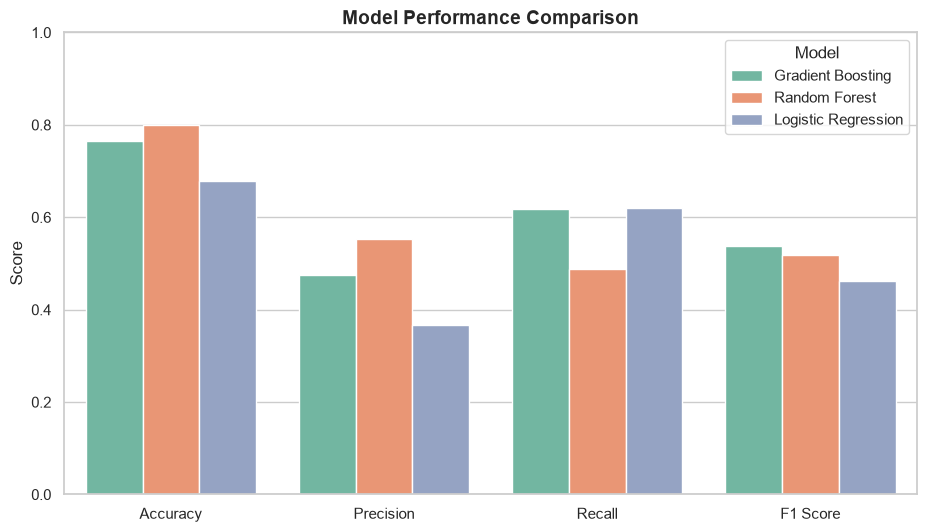

In [18]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf,
        accuracy_gb
    ],
    "Precision": [
        precision_logistic,
        precision_rf,
        precision_gb
    ],
    "Recall": [
        recall_logistic,
        recall_rf,
        recall_gb
    ],
    "F1 Score": [
        f1_logistic,
        f1_rf,
        f1_gb
    ]
})

results = results.sort_values("F1 Score", ascending=False).reset_index(drop=True)

display(results.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}"
}).highlight_max(axis=0, color="#C6EFCE"))

# Turn the table into a chart
results_melted = results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2"
)

plt.title("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("")
plt.legend(title="Model")
plt.show()

### Save the Final Model

In [19]:
import joblib

final_model = gradient_boosting_model
feature_names = X_train.columns.tolist()

# Save the trained model and the required input-column order
joblib.dump(
    final_model,
    "models/credit_default_gradient_boosting_model.joblib"
)

joblib.dump(
    feature_names,
    "models/feature_names.joblib"
)

print("Final model saved successfully.")
print("Model file: models/credit_default_gradient_boosting_model.joblib")
print("Number of required input features:", len(feature_names))

Final model saved successfully.
Model file: models/credit_default_gradient_boosting_model.joblib
Number of required input features: 23


## 7. Model Interpretation

### Most Important Features

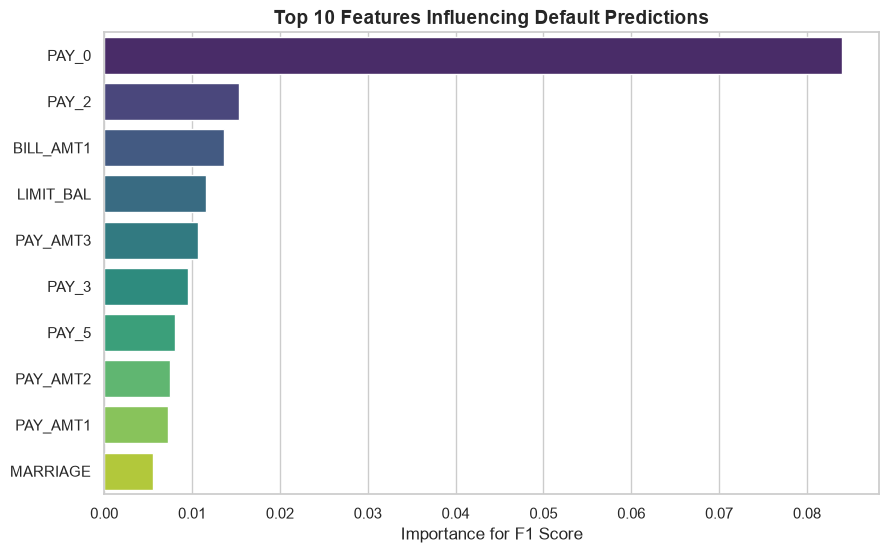

,Feature,Importance
5,PAY_0,0.084022
6,PAY_2,0.015367
11,BILL_AMT1,0.013592
0,LIMIT_BAL,0.011595
19,PAY_AMT3,0.010642
7,PAY_3,0.009510
9,PAY_5,0.008093
18,PAY_AMT2,0.007442
17,PAY_AMT1,0.007217
3,MARRIAGE,0.005605


In [20]:
from sklearn.inspection import permutation_importance

importance_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance_result.importances_mean
}).sort_values("Importance", ascending=False)

top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Features Influencing Default Predictions", fontsize=14, fontweight="bold")
plt.xlabel("Importance for F1 Score")
plt.ylabel("")
plt.show()

display(top_features)

## 8. Test a Saved Model Prediction

In [21]:
# Load the saved model from disk
loaded_model = joblib.load(
    "models/credit_default_gradient_boosting_model.joblib"
)

# Select one customer from the unseen test set
sample_customer = X_test.iloc[[0]]
actual_result = int(y_test.iloc[0])

# Ask the saved model for a prediction and probability
predicted_result = int(loaded_model.predict(sample_customer)[0])
default_probability = loaded_model.predict_proba(sample_customer)[0][1]

print(f"Actual outcome: {'Default' if actual_result == 1 else 'No Default'}")
print(f"Model prediction: {'Default' if predicted_result == 1 else 'No Default'}")
print(f"Predicted probability of default: {default_probability:.1%}")

Actual outcome: No Default
Model prediction: No Default
Predicted probability of default: 27.3%
